In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4008,ham,Ha... Then we must walk to everywhere... Canno...,NaN,NaN,NaN
4979,ham,So what u doing today?,NaN,NaN,NaN
4498,spam,"SMS SERVICES. for your inclusive text credits,...",NaN,NaN,NaN
1521,ham,Are you angry with me. What happen dear,NaN,NaN,NaN
3839,ham,HEY MATE! HOWS U HONEY?DID U AVE GOOD HOLIDAY?...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# Data cleaning
# EDA
# Text preprocessing
# Create the model
# Evaluation
# Optimization
# Website 
# Deploy

## 1. Data cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# Dropping last 3 columns

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis = 1, inplace = True)
df.sample(5)

,v1,v2
4663,ham,Mum not going robinson already.
2195,ham,V-aluable. A-ffectionate. L-oveable. E-ternal....
1444,ham,Those ducking chinchillas
2337,ham,Tell your friends what you plan to do on Valen...
1981,ham,"Sorry, I'll call later in meeting any thing re..."


In [8]:
# Renaming the columns

df.rename(columns={'v1' : 'Target', 'v2' : 'Text'}, inplace = True)
df.sample(5)

,Target,Text
4466,ham,"She said,'' do u mind if I go into the bedroom..."
1658,spam,RGENT! This is the 2nd attempt to contact U!U ...
3951,ham,Me hungry buy some food good lei... But mum n ...
5307,ham,What you did in leave.
1698,spam,"Free msg. Sorry, a service you ordered from 81..."


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['Target'] = encoder.fit_transform(df['Target'])      # Spam = 1 & Ham = 0
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# Missing values

df.isnull().sum()  # No null values

Target    0
Text      0
dtype: int64

In [12]:
# Duplicates

x = df.duplicated().sum()

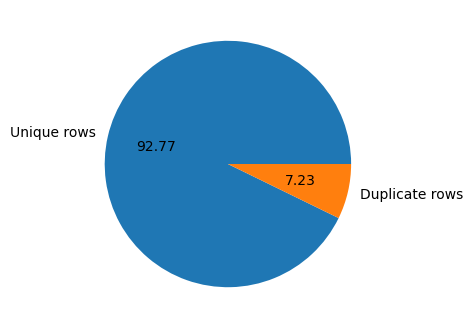

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize = (4,4))

duplicated_count = df.duplicated().value_counts()
labels = ['Unique rows' , 'Duplicate rows']
if   len(duplicated_count) == 2 :
    labels = ['Unique rows' , 'Duplicate rows']
else :
    labels = ['Duplicate rows']    

plt.pie(duplicated_count, labels = labels, autopct = "%0.2f")
plt.show()

In [14]:
# Removing duplicates

df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

## 2. EDA 

In [16]:
df.sample(5)

,Target,Text
2095,0,"Probably, want to pick up more?"
150,0,The wine is flowing and i'm i have nevering..
2011,0,Do whatever you want. You know what the rules ...
4325,0,That seems unnecessarily hostile
3802,0,Yup song bro. No creative. Neva test quality. ...


In [17]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

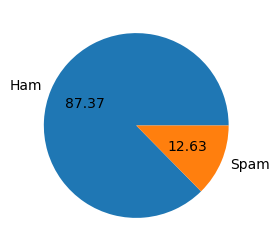

In [18]:
plt.figure(figsize = (3,3))
plt.pie(df['Target'].value_counts(), labels = ['Ham', 'Spam'], autopct = "%0.2f")
plt.show()

###                                             Data is unbalanced

In [19]:
# Create 3 new columns consisting num of characters,words and sentences

!pip install nltk

In [20]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\DHRUV KUMAR
[nltk_data]     BARNWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\DHRUV KUMAR
[nltk_data]     BARNWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\DHRUV KUMAR
[nltk_data]     BARNWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
df['Num_characters'] = df['Text'].apply(len) # find no of characters
df.head()

,Target,Text,Num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
df['Num_words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,Target,Text,Num_characters,Num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [23]:
df['Num_sentences'] = df['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.head()

,Target,Text,Num_characters,Num_words,Num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
df[['Num_words' , 'Num_characters' , 'Num_sentences']].describe()

,Num_words,Num_characters,Num_sentences
count,5169.000000,5169.000000,5169.000000
mean,18.455794,78.977945,1.965564
std,13.324758,58.236293,1.448541
min,1.000000,2.000000,1.000000
25%,9.000000,36.000000,1.000000
50%,15.000000,60.000000,1.000000
75%,26.000000,117.000000,2.000000
max,220.000000,910.000000,38.000000


In [25]:
# Ham data analysis
df[df['Target'] == 0][['Num_words' , 'Num_characters' , 'Num_sentences']].describe()

,Num_words,Num_characters,Num_sentences
count,4516.000000,4516.000000,4516.000000
mean,17.123782,70.459256,1.820195
std,13.493970,56.358207,1.383657
min,1.000000,2.000000,1.000000
25%,8.000000,34.000000,1.000000
50%,13.000000,52.000000,1.000000
75%,22.000000,90.000000,2.000000
max,220.000000,910.000000,38.000000


In [26]:
# Spam data analysis
df[df['Target'] == 1] [['Num_words' , 'Num_characters' , 'Num_sentences']].describe()

,Num_words,Num_characters,Num_sentences
count,653.000000,653.000000,653.000000
mean,27.667688,137.891271,2.970904
std,7.008418,30.137753,1.488425
min,2.000000,13.000000,1.000000
25%,25.000000,132.000000,2.000000
50%,29.000000,149.000000,3.000000
75%,32.000000,157.000000,4.000000
max,46.000000,224.000000,9.000000


In [27]:
import seaborn as sns

<Axes: xlabel='Num_characters', ylabel='Count'>

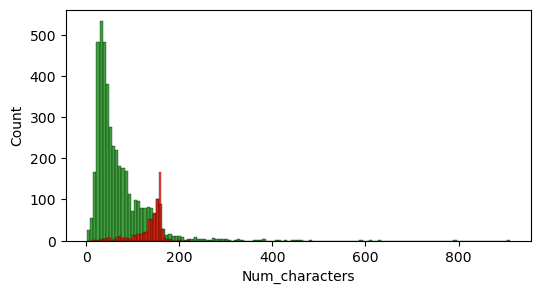

In [28]:
plt.figure(figsize = (6,3))
sns.histplot(df[df['Target']==0]['Num_characters'], color = 'green')
sns.histplot(df[df['Target']==1]['Num_characters'], color = 'red')

<Axes: xlabel='Num_words', ylabel='Count'>

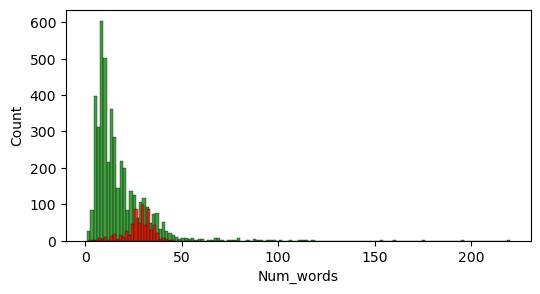

In [29]:
plt.figure(figsize = (6,3))
sns.histplot(df[df['Target']==0]['Num_words'], color = 'green')
sns.histplot(df[df['Target']==1]['Num_words'], color = 'red')

<Axes: xlabel='Num_sentences', ylabel='Count'>

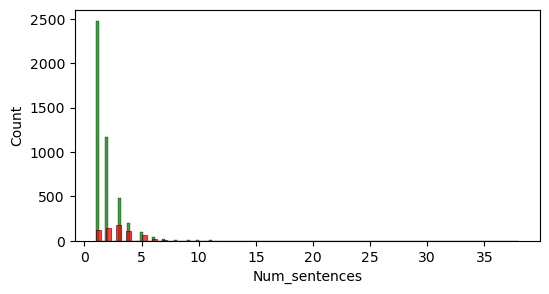

In [30]:
plt.figure(figsize = (6,3))
sns.histplot(df[df['Target']==0]['Num_sentences'], color = 'green')
sns.histplot(df[df['Target']==1]['Num_sentences'], color = 'red')

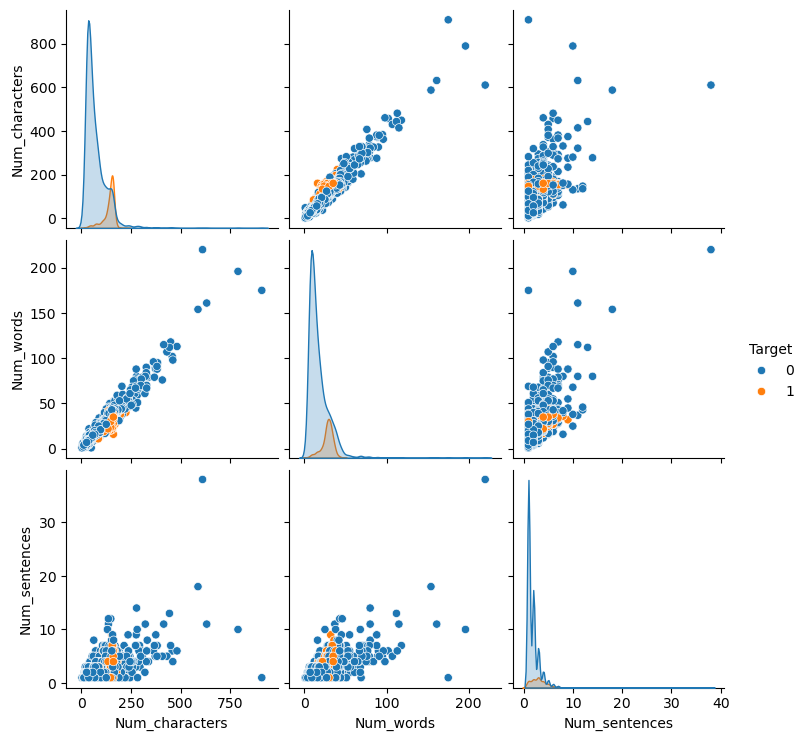

In [31]:
sns.pairplot(df, hue = 'Target')

In [32]:
# Relation of num_characters and num_words is near linear
# While the relation of num_sentences and others is also correlated

In [33]:
df.corr(numeric_only = True)

,Target,Num_characters,Num_words,Num_sentences
Target,1.000000,0.384717,0.262912,0.263939
Num_characters,0.384717,1.000000,0.965760,0.624139
Num_words,0.262912,0.965760,1.000000,0.679971
Num_sentences,0.263939,0.624139,0.679971,1.000000


####  The correlation between num_words and num_characters is very high 
####  The correlation between num_words and num_sentences is significantly high
####  The correlation between num_characters and num_sentences is also significantly high

<Axes: >

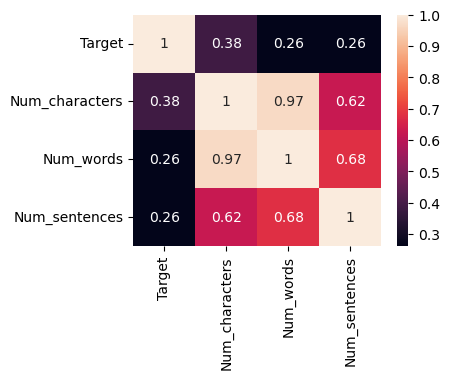

In [34]:
plt.figure(figsize = (4,3))
sns.heatmap(df.corr(numeric_only = True), annot = True)

#### Data preprocessing
1. Lower case
2. Tokenization
3. Removing special characters
4. Removing stop words and punctuations
5. Stemming or Lamitization -- Dance Dancing annd danced to dance 

In [35]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [36]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [37]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('working')

'work'

In [38]:
def transform_text (text) :
    text = text.lower()  # Lower case
    text = nltk.word_tokenize(text) # Tokenization text got converted into list here

    y = []
    for i in text :
         if i.isalnum() :
             y.append(i)  # Add only alpha numeric characters

    text = y[:]  # y is a list so we can't equate it to another variable directly   
    y.clear()

    for j in text :
        if j not in stopwords.words('english') and j not in string.punctuation :
            y.append(j) # Exclude the punctuations and stopwards

    text = y[:] 
    y.clear()
 
    for i in text :
        y.append(ps.stem(i))
    
    return " ".join(y) # Return as a string

In [39]:
txt = 'Hi how is your project going ? Akash !'
transform_text(txt)

'hi project go akash'

In [40]:
df['Transformed_text'] = df['Text'].apply(transform_text)
df.head()

,Target,Text,Num_characters,Num_words,Num_sentences,Transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [41]:
!pip install wordcloud

In [42]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'black')

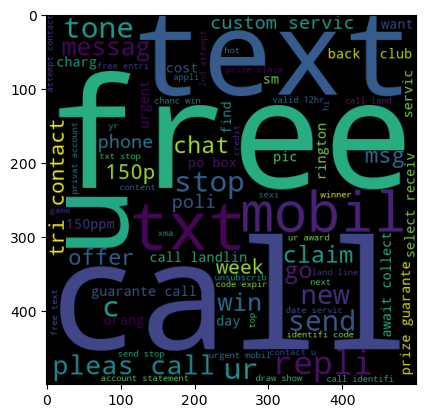

In [43]:
spam_wc = wc.generate(df[df['Target']==1]['Transformed_text'].str.cat(sep = " "))
plt.imshow(spam_wc)

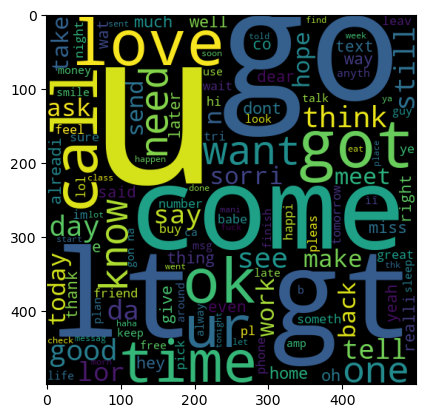

In [44]:
ham_wc = wc.generate(df[df['Target']==0]['Transformed_text'].str.cat(sep = " "))
plt.imshow(ham_wc)

In [45]:
# Storing each keyword of spam messages in a list

spam_corpus = []
for msg in df[df['Target']==1]['Transformed_text'].tolist() :
   for word in msg.split() :
     spam_corpus.append(word)

In [46]:
len(spam_corpus)

9939

In [47]:
ham_corpus = []

for msg in df[df['Target']==0]['Transformed_text'].tolist() :
    for word in msg.split() :
      ham_corpus.append(word)

In [48]:
len(ham_corpus)

35404

C:\Users\DHRUV KUMAR BARNWAL\AppData\Local\Temp\ipykernel_40740\1007332963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = spam_df, x = 'words' , y ='count', palette = 'husl')


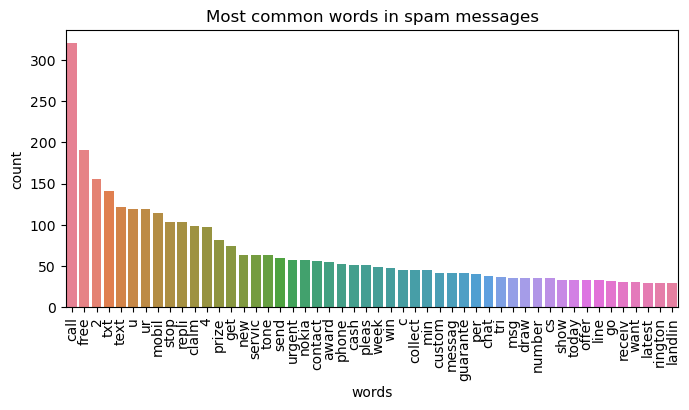

In [49]:
# Getting top 30 words in spam
plt.figure(figsize = (7,4))
from collections import Counter
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(50),columns = ['words' , 'count'])
sns.barplot(data = spam_df, x = 'words' , y ='count', palette = 'husl')
plt.xticks(rotation = 'vertical')
plt.tight_layout()
plt.title('Most common words in spam messages')
plt.show()

C:\Users\DHRUV KUMAR BARNWAL\AppData\Local\Temp\ipykernel_40740\1607814361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = ham_df , x = 'words', y = 'count', palette = 'husl')


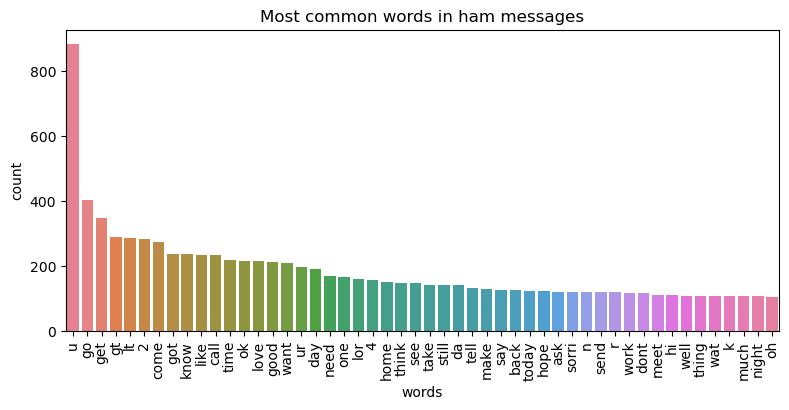

In [50]:
from collections import Counter
plt.figure(figsize = (8,4))
ham_df = pd.DataFrame(Counter(ham_corpus).most_common(50), columns = ['words' , 'count'])
sns.barplot(data = ham_df , x = 'words', y = 'count', palette = 'husl')
plt.xticks(rotation = 'vertical')
plt.tight_layout()
plt.title('Most common words in ham messages')
plt.show()

## Model buiding

In [51]:
# Vectorise the text using . bag of words (count vectorisor)
#                          . Tfidf vectoriser

In [52]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

#### Using TFIDF

In [53]:
X = tfidf.fit_transform(df['Transformed_text']).toarray()

In [54]:
np.unique(X)

array([0.        , 0.03821809, 0.04407572, ..., 0.9786767 , 0.98003659,
       1.        ], shape=(35921,))

In [55]:
X.shape  # reads 6000 words and convert them into numercical array 

(5169, 6708)

In [56]:
y = df['Target'].values
np.unique(y)

array([0, 1])

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 2)

In [58]:
# Applying different naive biases
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
# Precision score is the most important evaluation metric here as the false positives should be min in case of spam emails

In [59]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [59]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred1))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred1))
print('precision score : ', precision_score(y_test, y_pred1))

accuracy :  0.8762088974854932
Confusion matrix : 
[[793 103]
 [ 25 113]]
precision score :  0.5231481481481481


In [60]:
bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred2))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred2))
print('precision score : ', precision_score(y_test, y_pred2))

accuracy :  0.9700193423597679
Confusion matrix : 
[[893   3]
 [ 28 110]]
precision score :  0.9734513274336283


In [61]:
mnb.fit(X_train, y_train)
y_pred3 = mnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred3))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred3))
print('precision score : ', precision_score(y_test, y_pred3))

accuracy :  0.9593810444874274
Confusion matrix : 
[[896   0]
 [ 42  96]]
precision score :  1.0


#### Using Bag of words

In [62]:
X = cv.fit_transform(df['Transformed_text']).toarray()

In [63]:
np.unique(X)

array([ 0,  1,  2,  3,  4,  5,  6,  8, 10, 15, 18])

In [64]:
X.shape  # reads 6000 words and convert them into array acc to the frequency of their occurence

(5169, 6708)

In [65]:
y = df['Target'].values
np.unique(y)

array([0, 1])

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 2)

In [67]:
# Applying different naive biases
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
# Precision score is the most important evaluation metric here as the false positives should be min in case of spam emails

In [68]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred1))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred1))
print('precision score : ', precision_score(y_test, y_pred1))

accuracy :  0.8800773694390716
Confusion matrix : 
[[792 104]
 [ 20 118]]
precision score :  0.5315315315315315


In [69]:
bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred2))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred2))
print('precision score : ', precision_score(y_test, y_pred2))

accuracy :  0.9700193423597679
Confusion matrix : 
[[893   3]
 [ 28 110]]
precision score :  0.9734513274336283


In [70]:
mnb.fit(X_train, y_train)
y_pred3 = mnb.predict(X_test)
print('accuracy : ', accuracy_score(y_test, y_pred3))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred3))
print('precision score : ', precision_score(y_test, y_pred3))

accuracy :  0.9642166344294004
Confusion matrix : 
[[871  25]
 [ 12 126]]
precision score :  0.8344370860927153


### The Tfidf is giving us more better precision score but the accuracy score is almost same in both vectorisers

In [61]:
tfidf2 = TfidfVectorizer(max_features= 4300) # Set the max limit to 1000 words

In [63]:
X_ = tfidf2.fit_transform(df['Transformed_text']).toarray()

In [71]:
# Methods to increase the accuracy of tfidf + mnb approach

# Add the max limit of words in tfidf vectoriser
# Scaling the X by min_max scaler       ---- Not much affect
# # appending the num_character col to X  -------Not much effect

In [64]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# X_ = scaler.fit_transform(X_)

In [65]:
# X_ = np.hstack((X_,df['Num_characters'].values.reshape(-1,1)))

In [66]:
X_.shape

(5169, 4300)

In [67]:
y_ = df['Target'].values
y_

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_,y_, test_size = 0.2, random_state = 2)

In [69]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('accuracy : ', (accuracy_score(y_test, y_pred1))*100)
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred1))
print('precision score : ', (precision_score(y_test, y_pred1))*100)

accuracy :  87.62088974854933
Confusion matrix : 
[[793 103]
 [ 25 113]]
precision score :  52.31481481481482


In [70]:
mnb.fit(X_train, y_train)
y_pred3 = mnb.predict(X_test)
print('accuracy : ', (accuracy_score(y_test, y_pred3))*100)
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred3))
print('precision score : ', (precision_score(y_test, y_pred3))*100)

accuracy :  96.71179883945842
Confusion matrix : 
[[896   0]
 [ 34 104]]
precision score :  100.0


In [73]:
bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)
print('accuracy : ', (accuracy_score(y_test, y_pred2)*100))
print('Confusion matrix : ')
print(confusion_matrix(y_test, y_pred2))
print('precision score : ', (precision_score(y_test, y_pred2))*100)

accuracy :  98.25918762088975
Confusion matrix : 
[[896   0]
 [ 18 120]]
precision score :  100.0


In [74]:
import pickle
model = BernoulliNB()
model.fit(X_train, y_train)

pickle.dump(tfidf2, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))